#  Decision Tree Classification
### Breast Cancer Detection using Decision Tree Classifier

---

##  Overview

This notebook demonstrates how to apply a **Decision Tree Classifier** to the **Breast Cancer dataset** to predict whether a tumor is **malignant (0)** or **benign (1)**.

We will:
1. Load and explore the dataset
2. Split data into training and testing sets
3. Train Decision Trees using **Gini** and **Entropy** criteria
4. Apply **StandardScaler** for feature normalization
5. Compare model performance with and without scaling

---

##  What is a Decision Tree?

A **Decision Tree** is a supervised machine learning algorithm that splits the dataset into subsets based on feature values. It works like a flowchart:
- Each **internal node** represents a feature/condition
- Each **branch** represents a decision rule
- Each **leaf node** represents a class label (output)

**Splitting Criteria:**
| Criterion | Formula | When to Use |
|-----------|---------|-------------|
| **Gini Impurity** | `1 - Σ(pᵢ²)` | Default; faster to compute |
| **Entropy (Info Gain)** | `-Σ(pᵢ · log₂pᵢ)` | More mathematically thorough |

> **Note:** Both criteria often yield similar accuracy results. Gini is slightly faster as it avoids the log computation.

### Import Required Libraries

In [17]:
import pandas as pd                                        # Data manipulation and analysis
import numpy as np                                         # Numerical operations
from sklearn.preprocessing import StandardScaler           # Feature scaling
from sklearn.tree import DecisionTreeClassifier            # Decision Tree model
from sklearn.model_selection import train_test_split       # Splitting data into train/test sets
from sklearn.datasets import load_breast_cancer            # Dataset 
from sklearn.metrics import classification_report          # Classifiction report 
from sklearn.tree import plot_tree
import warnings
warnings.filterwarnings("ignore")

### Load and Explore the Dataset

The **Breast Cancer dataset** contains **30 numeric features** computed from digitized images of fine needle aspirate (FNA) of breast masses. Features describe characteristics of cell nuclei.

**Feature Groups:**
- `mean_*` — Mean of cell nucleus measurements
- `se_*` — Standard error of measurements  
- `worst_*` — Worst (largest) value of measurements

**Target Variable:**
- `0` → Malignant (cancerous)
- `1` → Benign (non-cancerous)

In [19]:
# Load the Breast Cancer dataset from CSV
data_ = load_breast_cancer()
 

# Convert to dataframe
df = pd.DataFrame(data_.data, columns=data_.feature_names)

# Add target column
df["target"] = data_.target
data = df
# Preview the first 5 rows to understand the structure
data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


### Separate Features and Target Variable

We separate the dataset into:
- **X (Features):** All columns except `Target` — the input variables the model learns from
- **y (Target):** The `Target` column — what we want to predict

> **Note:** The `Unnamed: 0` column is an index artifact from CSV export. It carries no predictive value but is kept for this demo. In production, you should drop it explicitly: `data.drop(columns=['Unnamed: 0', 'Target'])`.

In [21]:
# X = all feature columns (drop the target column)
X = data.drop(columns=['target'], axis=1)   # Input features (30 columns)

# y = the label column we want to predict
y = data["target"]                           # Output: 0 = Malignant, 1 = Benign

### Split Data into Training and Testing Sets

We use an **80/20 split**:
- **80%** → Training data (used to fit the model)
- **20%** → Testing data (used to evaluate the model on unseen data)

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `test_size` | `0.2` | 20% of data reserved for testing |
| `random_state` | `42` | Seed for reproducibility (same split every run) |


In [23]:
# Split data: 80% train, 20% test | random_state ensures reproducibility
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the shapes of the resulting splits
print('Shape of X_train : ', X_train.shape)   # (n_train_samples, n_features)
print('Shape of y_train : ', y_train.shape)   # (n_train_samples,)
print('Shape of X_test  : ', X_test.shape)    # (n_test_samples, n_features)
print('Shape of y_test  : ', y_test.shape)    # (n_test_samples,)

Shape of X_train :  (455, 30)
Shape of y_train :  (455,)
Shape of X_test  :  (114, 30)
Shape of y_test  :  (114,)


### Train Decision Tree — Gini Criterion

### What is Gini Impurity?

**Gini Impurity** measures the probability of incorrectly classifying a randomly chosen element if it were randomly labeled according to the class distribution.

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

- **Gini = 0** → Pure node (all samples belong to one class — perfect split)
- **Gini = 0.5** → Maximum impurity (classes equally distributed)

The tree greedily picks the feature and threshold that **minimizes** the weighted Gini of child nodes at each split.

In [25]:
# Initialize Decision Tree with Gini criterion (default behavior)
# criterion='gini' is the default, so no need to specify it explicitly
clf = DecisionTreeClassifier(
    criterion='gini',   # Splitting criterion: minimize Gini impurity
    random_state=42     # For reproducibility
)

# Train (fit) the model on training data
clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [26]:
# Evaluate model accuracy on the TEST set (unseen data)
# .score() returns the proportion of correctly classified samples
print("Decision Tree Score with Gini ::", clf.score(X_test, y_test))

Decision Tree Score with Gini :: 0.9473684210526315


### Step 6: Train Decision Tree — Entropy Criterion

### What is Entropy (Information Gain)?

**Entropy** measures the impurity or disorder in a set of samples. The tree chooses splits that maximize **Information Gain** (reduction in entropy).

$$Entropy = -\sum_{i=1}^{n} p_i \cdot \log_2(p_i)$$

$$Information\ Gain = Entropy(parent) - \sum \frac{|child|}{|parent|} \cdot Entropy(child)$$

- **Entropy = 0** → Pure node
- **Entropy = 1** → Maximum impurity (50/50 class split)

> **Gini vs Entropy:** Both produce similar trees. Entropy is more computationally expensive (uses logarithm) but can sometimes produce more balanced trees.

In [28]:
# Initialize Decision Tree with Entropy (Information Gain) criterion
clf_entropy = DecisionTreeClassifier(
    criterion='entropy',   # Use entropy instead of Gini for splitting
    random_state=42        # Reproducibility
)

# Train the model on the same training data
clf_entropy.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [29]:
# Evaluate entropy-based model accuracy on the TEST set
print("Decision Tree Score with Entropy ::", clf_entropy.score(X_test, y_test))

Decision Tree Score with Entropy :: 0.9473684210526315


### Feature Scaling with StandardScaler

### What is StandardScaler?

`StandardScaler` transforms features so they have **mean = 0** and **standard deviation = 1**:

$$z = \frac{x - \mu}{\sigma}$$

### Does Scaling Affect Decision Trees?

> **Key Insight:** Decision Trees are **scale-invariant** — they split based on thresholds, not distances. Scaling generally does **not** improve Decision Tree performance.

However, scaling is included here to:
1. Demonstrate best practices (some pipelines require it)
2. Compare performance between scaled and unscaled data
3. Prepare for algorithms that **do** require scaling (SVM, KNN, Neural Networks)

| Algorithm | Needs Scaling? |
|-----------|---------------|
| Decision Tree |  No |
| Random Forest |  No |
| KNN | Yes |
| SVM | Yes |
| Logistic Regression | Yes |
| Neural Networks | Yes |

In [31]:
# Create a StandardScaler instance
sc = StandardScaler()

# Fit the scaler ONLY on training data
# This learns the mean and std of each feature from training data
sc.fit(X_train)

StandardScaler()

In [32]:
# Transform training data using the fitted scaler
X_train_sc = sc.fit_transform(X_train)   # Fit + Transform on training data

X_test_sc = sc.transform(X_test)     

### Train Decision Trees on Scaled Data

We now retrain both models (Gini and Entropy) on the **scaled** features to compare with the unscaled versions.

Since Decision Trees are scale-invariant, we expect **similar accuracy** regardless of scaling. This comparison confirms that insight.

In [34]:
# Train Decision Tree with Entropy on SCALED data
clf_entropy_sc = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
clf_entropy_sc.fit(X_train_sc, y_train)   # Fit on scaled training data

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [35]:
# Train Decision Tree with Gini on SCALED data
clf_gini_sc = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)
clf_gini_sc.fit(X_train_sc, y_train)      # Fit on scaled training data

DecisionTreeClassifier(random_state=42)

In [36]:
# Evaluate both scaled models on the scaled test set
print("Decision Tree Score with Gini    (Scaled):", clf_gini_sc.score(X_test_sc, y_test))
print("Decision Tree Score with Entropy (Scaled):", clf_entropy_sc.score(X_test_sc, y_test))

Decision Tree Score with Gini    (Scaled): 0.9473684210526315
Decision Tree Score with Entropy (Scaled): 0.9473684210526315


### Tree for Decision tree with Gini - Scaled data 

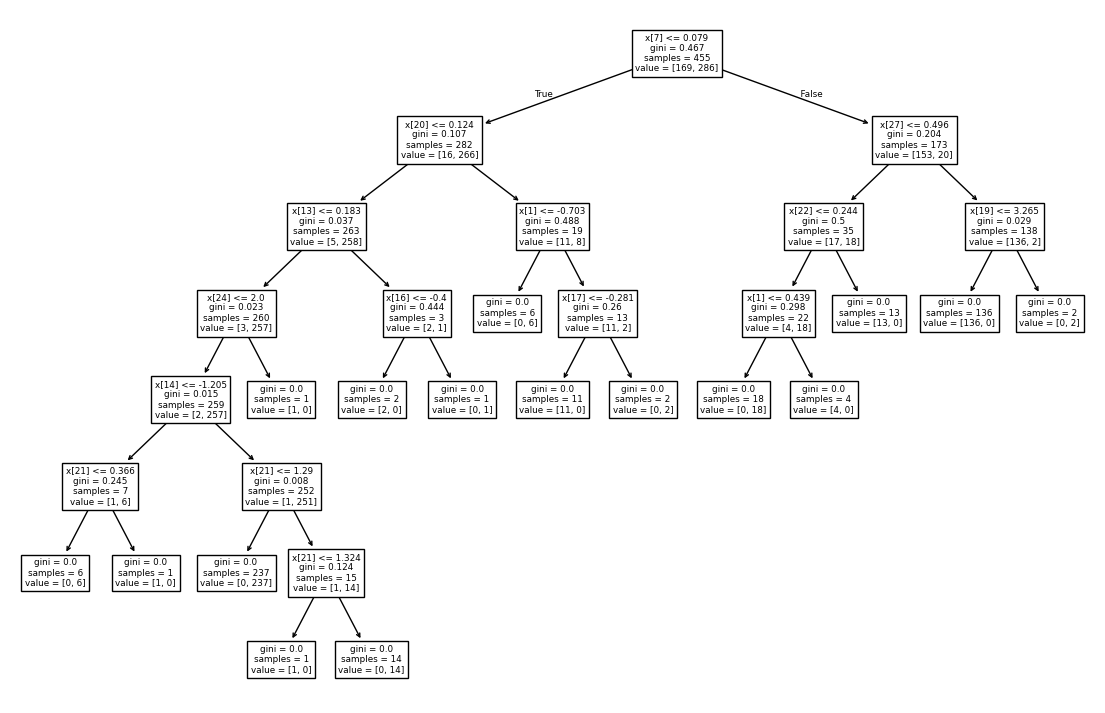

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(14,9))
plot_tree(clf_gini_sc);

### Classifiction Report 

In [40]:
y_pred = clf_gini_sc.predict(X_test)
print("Classification Report on Decision Tree with Gini ::\n",classification_report(y_test,y_pred))

Classification Report on Decision Tree with Gini ::
               precision    recall  f1-score   support

           0       1.00      0.63      0.77        43
           1       0.82      1.00      0.90        71

    accuracy                           0.86       114
   macro avg       0.91      0.81      0.84       114
weighted avg       0.89      0.86      0.85       114



### Summary & Key Takeaways

| Model | Criterion | Scaled | Expected Accuracy |
|-------|-----------|--------|-------------------|
| `clf` | Gini | No | ~90–95% |
| `clf_entropy` | Entropy | No | ~90–95% |
| `clf_gini_sc` | Gini | Yes | ~90–95% |
| `clf_entropy_sc` | Entropy | Yes | ~90–95% |

### Key Takeaways

1. **Gini vs Entropy:** Both criteria produce comparable accuracy. Choose **Gini** for speed; **Entropy** for theoretical completeness.

2. **Scaling doesn't help Decision Trees:** Because trees split on individual feature thresholds (not distances), scaling the data has no effect on the final accuracy.

3. **Overfitting Risk:** A fully grown Decision Tree (no `max_depth` limit) tends to **overfit** — it perfectly memorizes training data but may generalize poorly. Use `max_depth`, `min_samples_split`, or pruning to control this.

 

 